# Piece-Wise Nature of Z + TVT
* $TVT = -Z + m * MD + c$, where m and c change for each chunk.
* $TVT\ vs\ MD$ can have vertical jumps (discontinuity).
* $ TVT + Z = Piece-Wise\ Linear\ Function $ 

In [1]:
import os
import glob
import numpy as np
np.random.seed(123456789)
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Automatically detect if running on Kaggle or Locally
IS_KAGGLE = os.path.exists('/kaggle/input')
BASE_DIR = '/kaggle/input/competitions/rogii-wellbore-geology-prediction' if IS_KAGGLE else '../data'

print(f"Running on {'Kaggle' if IS_KAGGLE else 'Local Environment'}")
print(f"Data Directory: {BASE_DIR}")
train_data = os.path.join(BASE_DIR, "train")
file_paths = sorted(os.listdir(train_data))

# Regex pattern: 
pattern = re.compile(r'([^/\\]+)__horizontal_well\.csv')

well_names = []
for path in file_paths:
    match = pattern.search(path)
    if match:
        well_names.append(match.group(1))

print("Extracted Well Names:")
print(len(well_names), "Well Names")

Running on Local Environment
Data Directory: ../data
Extracted Well Names:
773 Well Names


In [3]:
well = np.random.choice(well_names)

hw = pd.read_csv(train_data + f"/{well}__horizontal_well.csv")
tw = pd.read_csv(train_data + f"/{well}__typewell.csv")

mask = hw['TVT_input'].isna()
evalz = hw[mask].copy()
tvt0 = hw[~mask]['TVT'].iloc[-1]

well, hw.shape, tw.shape, evalz.shape

(np.str_('ea3a0e38'), (11794, 13), (3652, 3), (10052, 13))

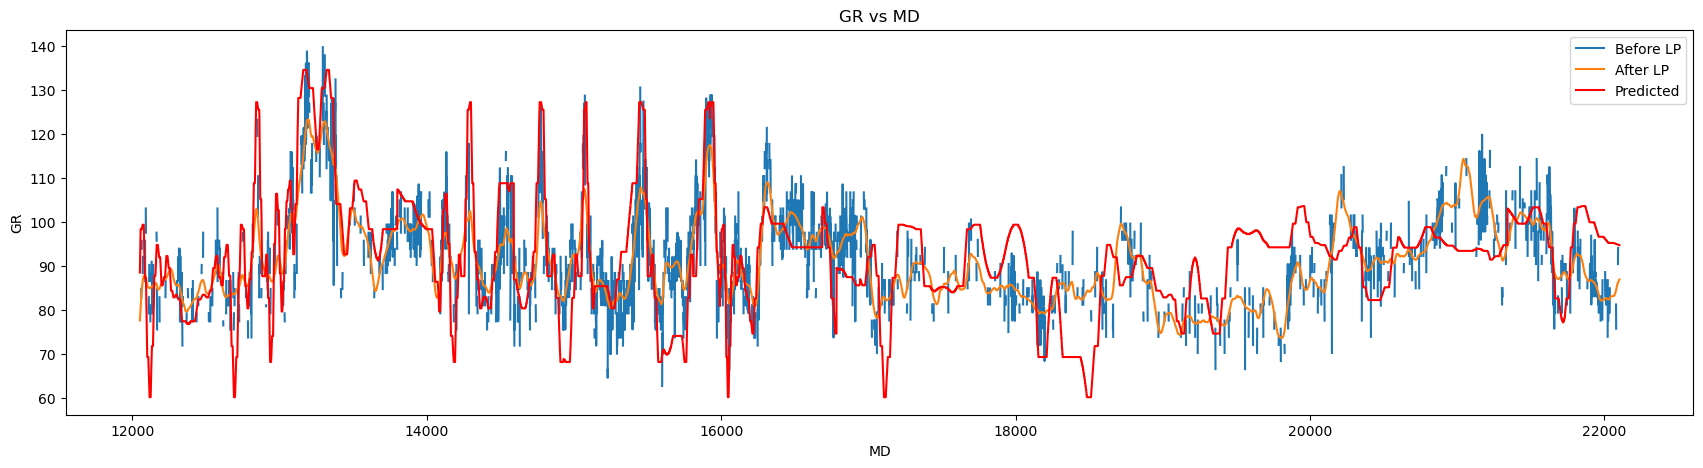

In [4]:
from scipy.signal import butter, filtfilt
from scipy.stats import pearsonr

HW_LOW_PASS_CUTOFF = 0.009
def remove_rotation_noise(gr_series, cutoff=HW_LOW_PASS_CUTOFF):
    """Low pass filter."""
    gr_filled = gr_series.interpolate(method='linear').bfill().ffill()
    nyquist = 0.5 
    normal_cutoff = cutoff / nyquist
    b, a = butter(1, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, gr_filled)

plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['GR'], label='Before LP')
    
evalz['GR'] = remove_rotation_noise(evalz['GR'])
pred_gr = np.interp(evalz['TVT'], tw['TVT'], tw['GR'])

plt.plot(evalz['MD'], evalz['GR'], label='After LP')
plt.plot(evalz['MD'], pred_gr, label='Predicted', color='red')
plt.title('GR vs MD')
plt.xlabel('MD')
plt.ylabel('GR')
plt.legend()

Text(0.5, 1.0, 'Pearson Correlation: 0.406108479992286, m: -0.01993365571991887, c: -8638.747478437042')

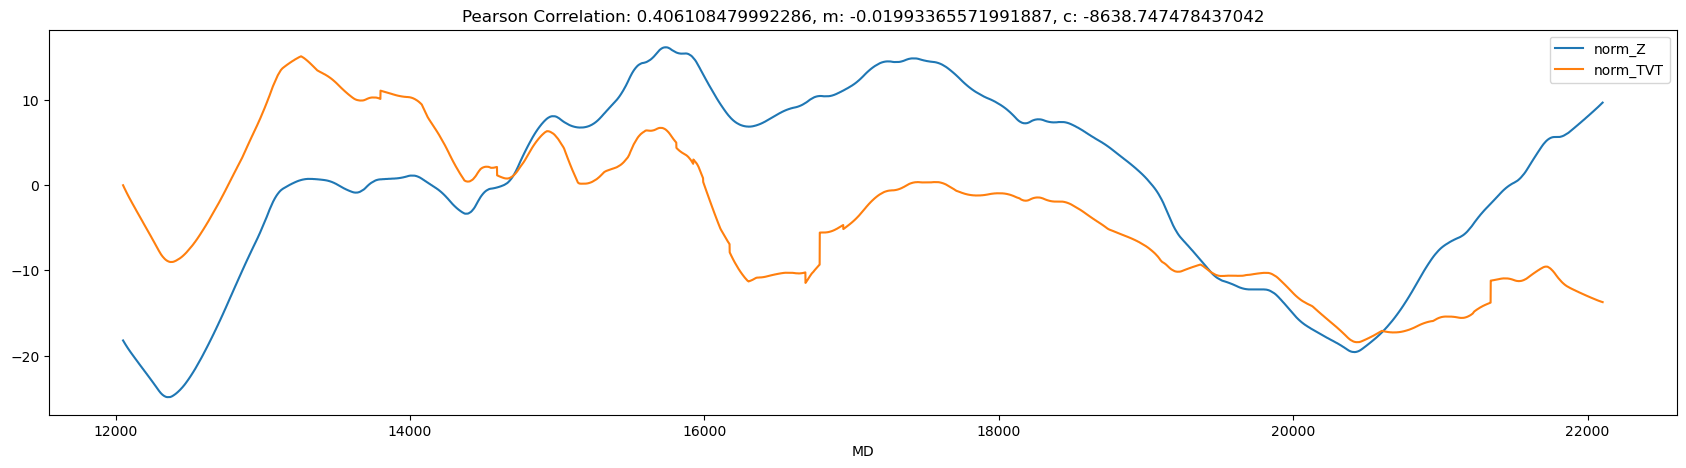

In [5]:
m_z, c_z = np.polyfit(evalz['MD'], evalz['Z'], deg=1)
evalz['norm_Z'] = (m_z * evalz['MD'] + c_z) - evalz['Z']
evalz['norm_TVT'] = evalz['TVT'] - tvt0
evalz['Z+TVT'] = evalz['norm_TVT'] - evalz['norm_Z'] 
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['norm_Z'], label='norm_Z')
plt.plot(evalz['MD'], evalz['norm_TVT'], label='norm_TVT')
plt.xlabel('MD')
plt.legend()
plt.title(f'Pearson Correlation: {np.corrcoef(evalz['norm_Z'], evalz['norm_TVT'])[0, 1]}, m: {m_z}, c: {c_z}')

Text(0, 0.5, 'Z + TVT')

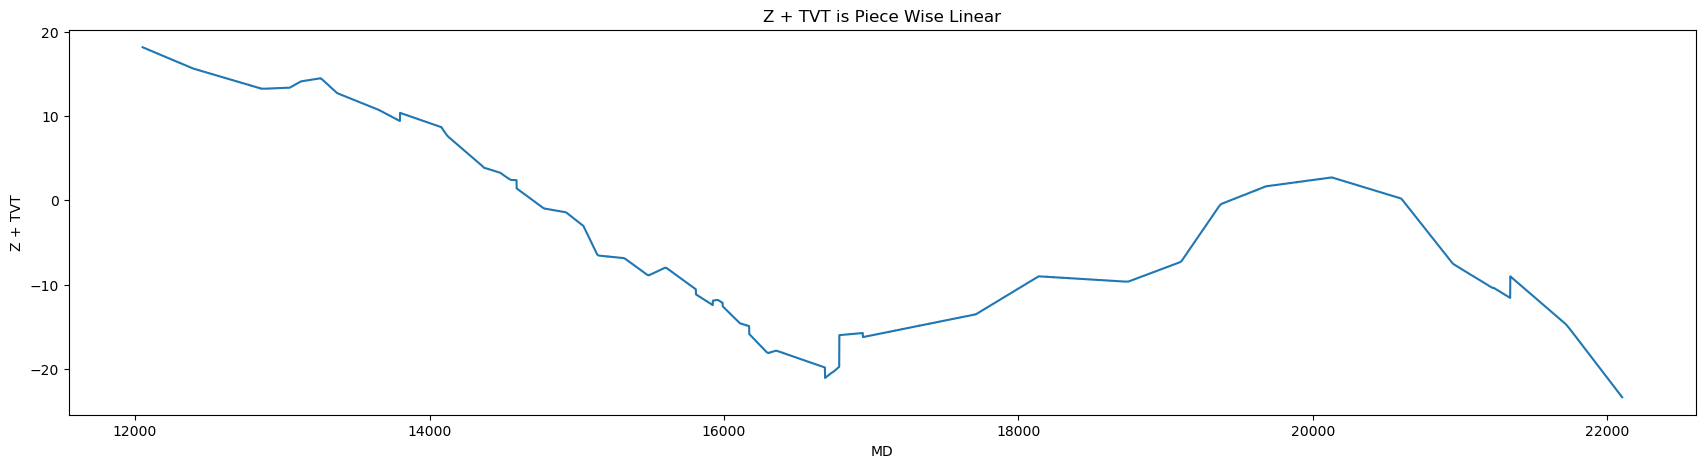

In [6]:
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['Z+TVT'])
plt.title('Z + TVT is Piece Wise Linear')
plt.xlabel('MD')
plt.ylabel('Z + TVT')

45

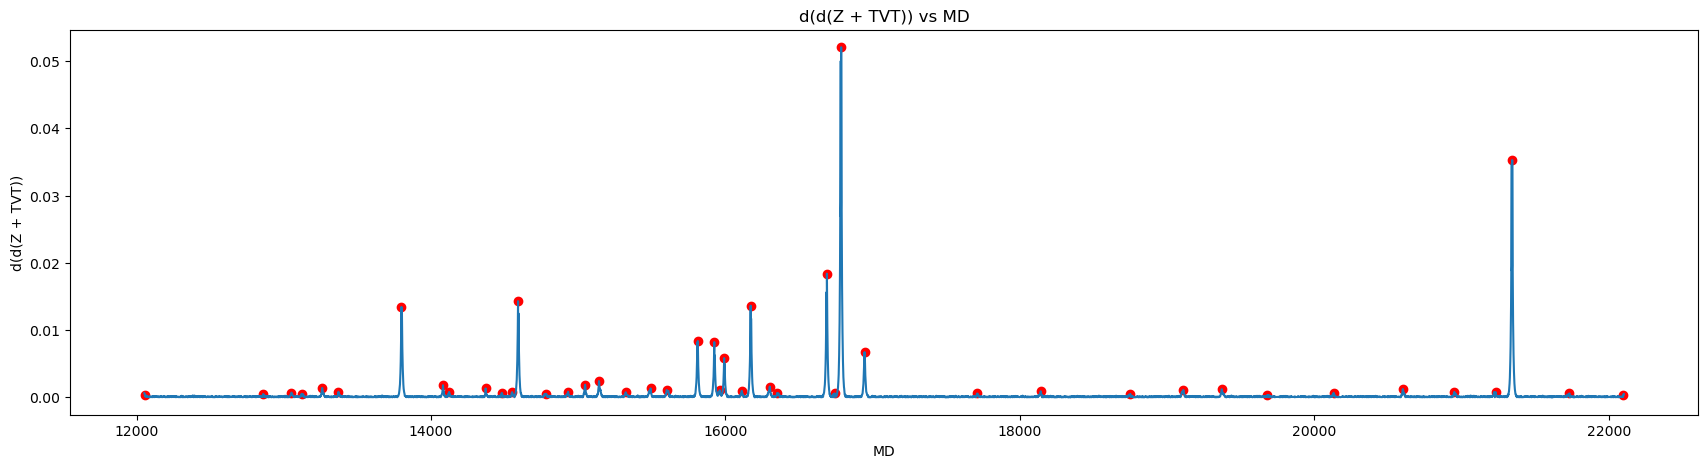

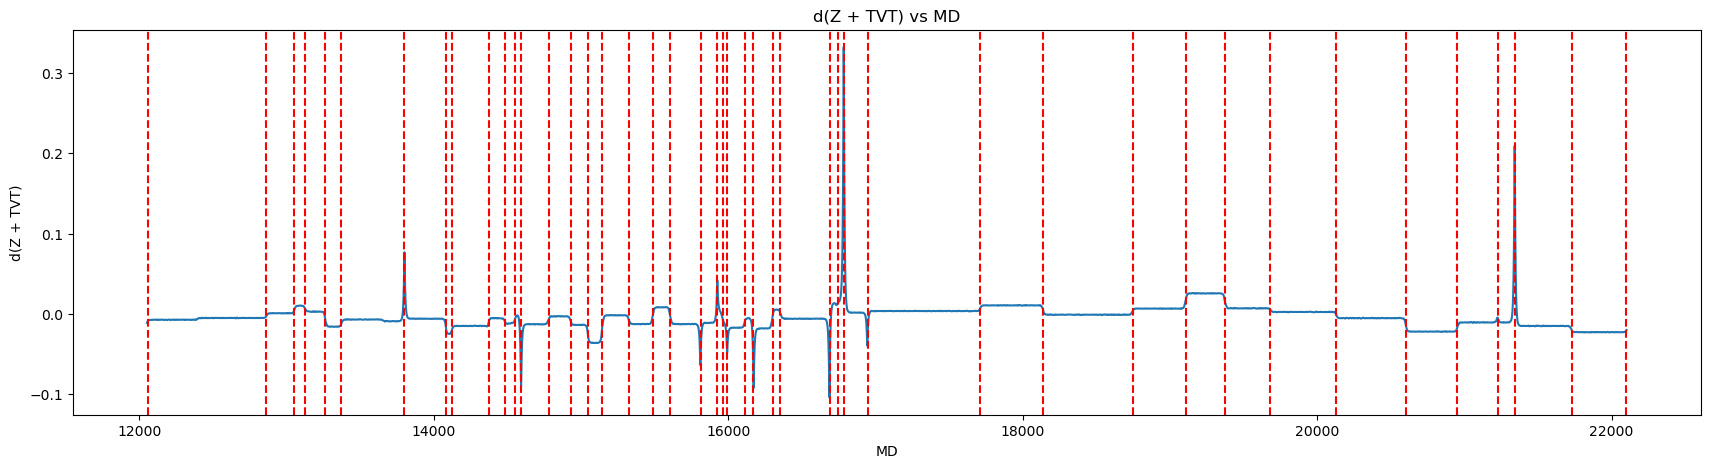

In [7]:
d = lambda df: df.diff()#.rolling(window=3).mean()
evalz['dZ+dTVT'] = remove_rotation_noise(d(evalz['Z+TVT']), cutoff=0.03)

from scipy.signal import find_peaks
plt.figure(figsize=(21, 5))
dd = np.abs(d(evalz['dZ+dTVT']))
peaks, properties = find_peaks(dd, distance=30, height=0.0003)
plt.plot(evalz['MD'], dd)
plt.scatter(evalz['MD'].iloc[peaks], dd.iloc[peaks], color='red')
plt.title('d(d(Z + TVT)) vs MD')
plt.ylabel('d(d(Z + TVT))')
plt.xlabel('MD')

plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['dZ+dTVT'])
plt.title('d(Z + TVT) vs MD')
plt.ylabel('d(Z + TVT)')
plt.xlabel('MD')
for pos in evalz['MD'].iloc[peaks]:
    plt.axvline(x=pos, color='r', linestyle='--')
len(peaks)

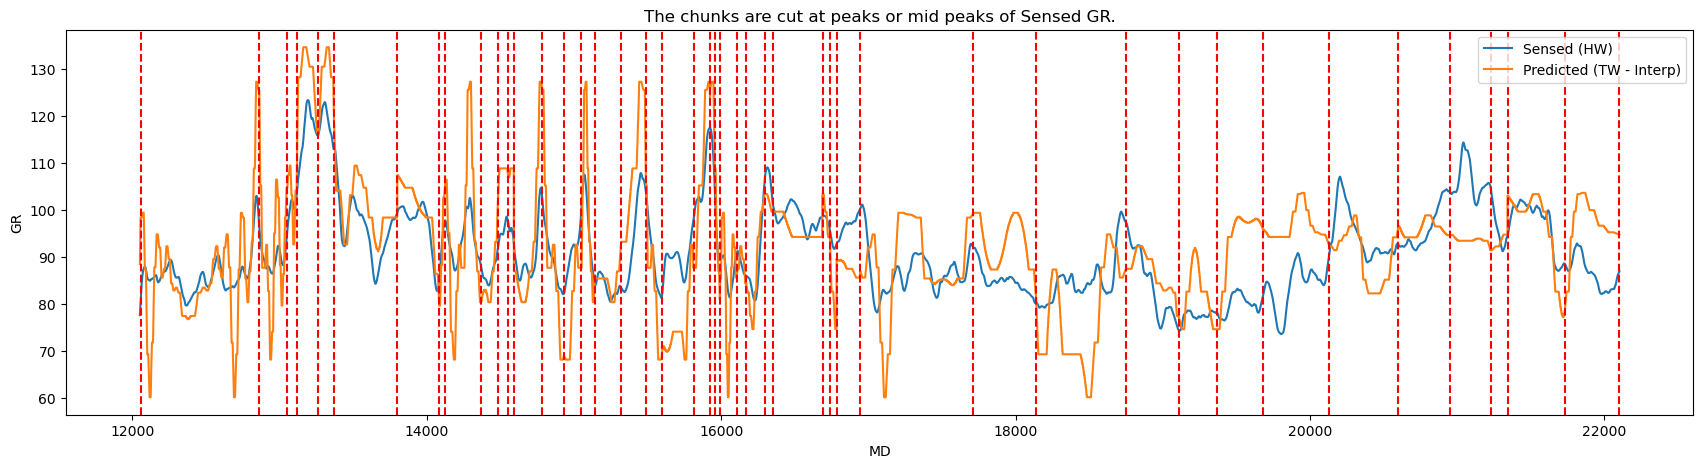

In [8]:
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['GR'], label='Sensed (HW)')
plt.plot(evalz['MD'], np.interp(evalz['TVT'], tw['TVT'], tw['GR']), label='Predicted (TW - Interp)')
plt.title('The chunks are cut at peaks or mid peaks of Sensed GR.')
plt.xlabel('MD')
plt.ylabel('GR')
plt.legend()
for pos in evalz['MD'].iloc[peaks]:
    plt.axvline(x=pos, color='r', linestyle='--')

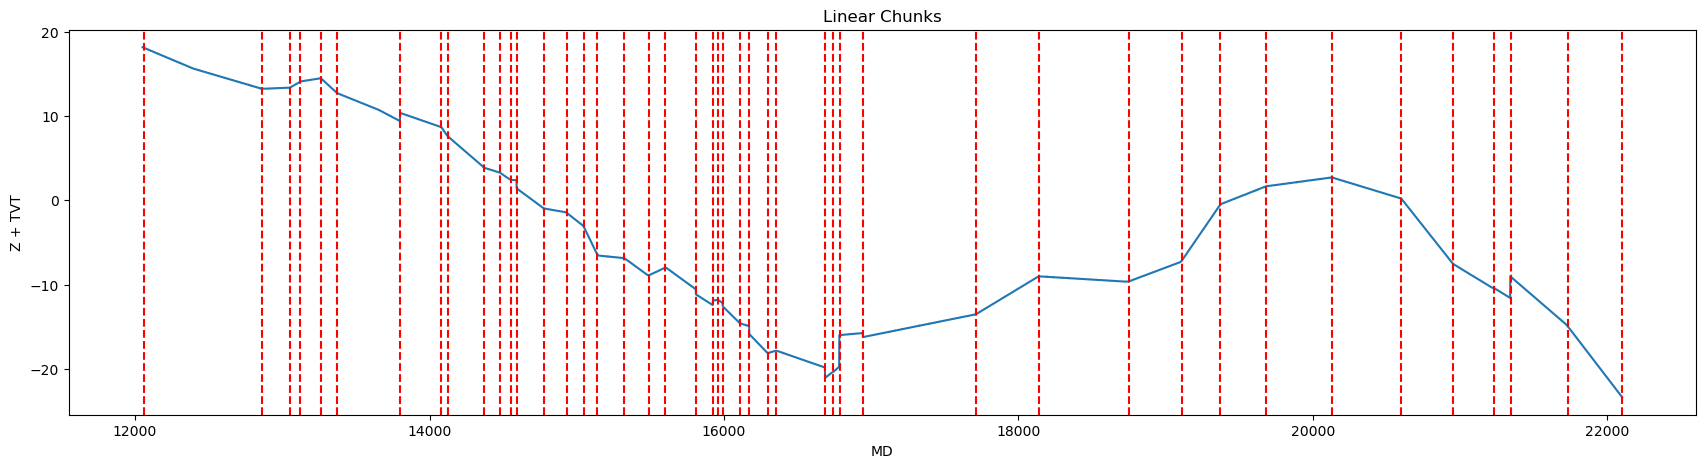

In [9]:
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['Z+TVT'])
plt.title('Linear Chunks')
plt.xlabel('MD')
plt.ylabel('Z + TVT')
for pos in evalz['MD'].iloc[peaks]:
    plt.axvline(x=pos, color='r', linestyle='--')

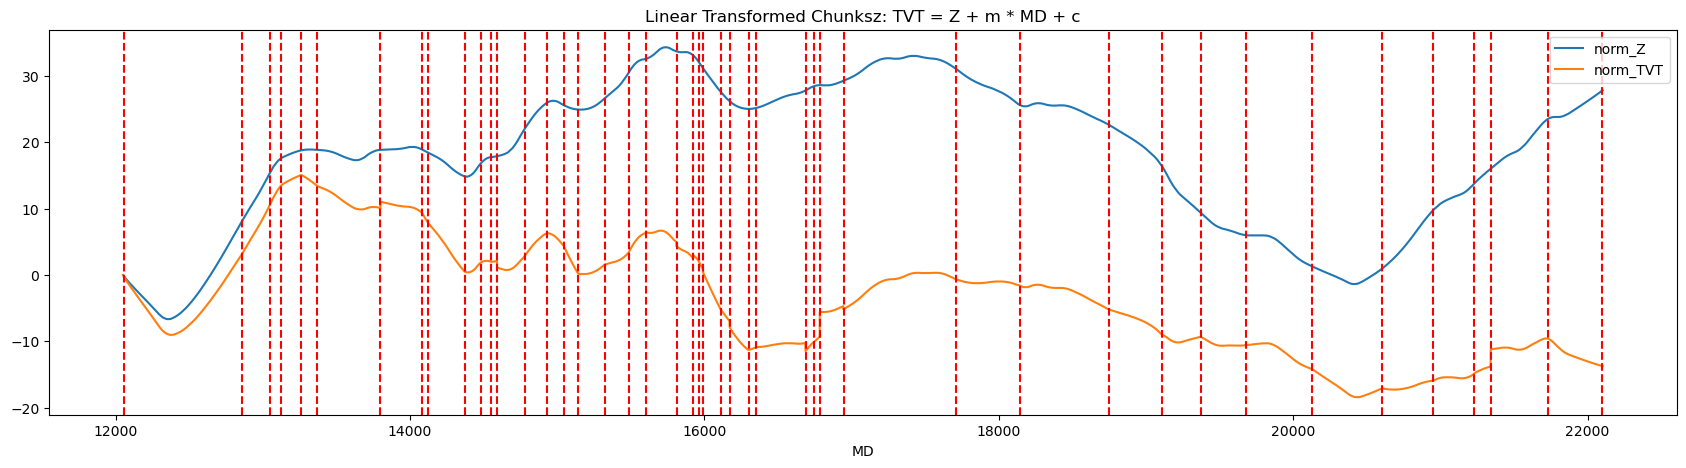

In [10]:
plt.figure(figsize=(21, 5))
plt.title('Linear Transformed Chunksz: TVT = Z + m * MD + c')
plt.plot(evalz['MD'], evalz['norm_Z'] - evalz['norm_Z'].iloc[0], label='norm_Z')
plt.plot(evalz['MD'], evalz['norm_TVT'], label='norm_TVT')
plt.xlabel('MD')
plt.legend()
for pos in evalz['MD'].iloc[peaks]:
    plt.axvline(x=pos, color='r', linestyle='--')

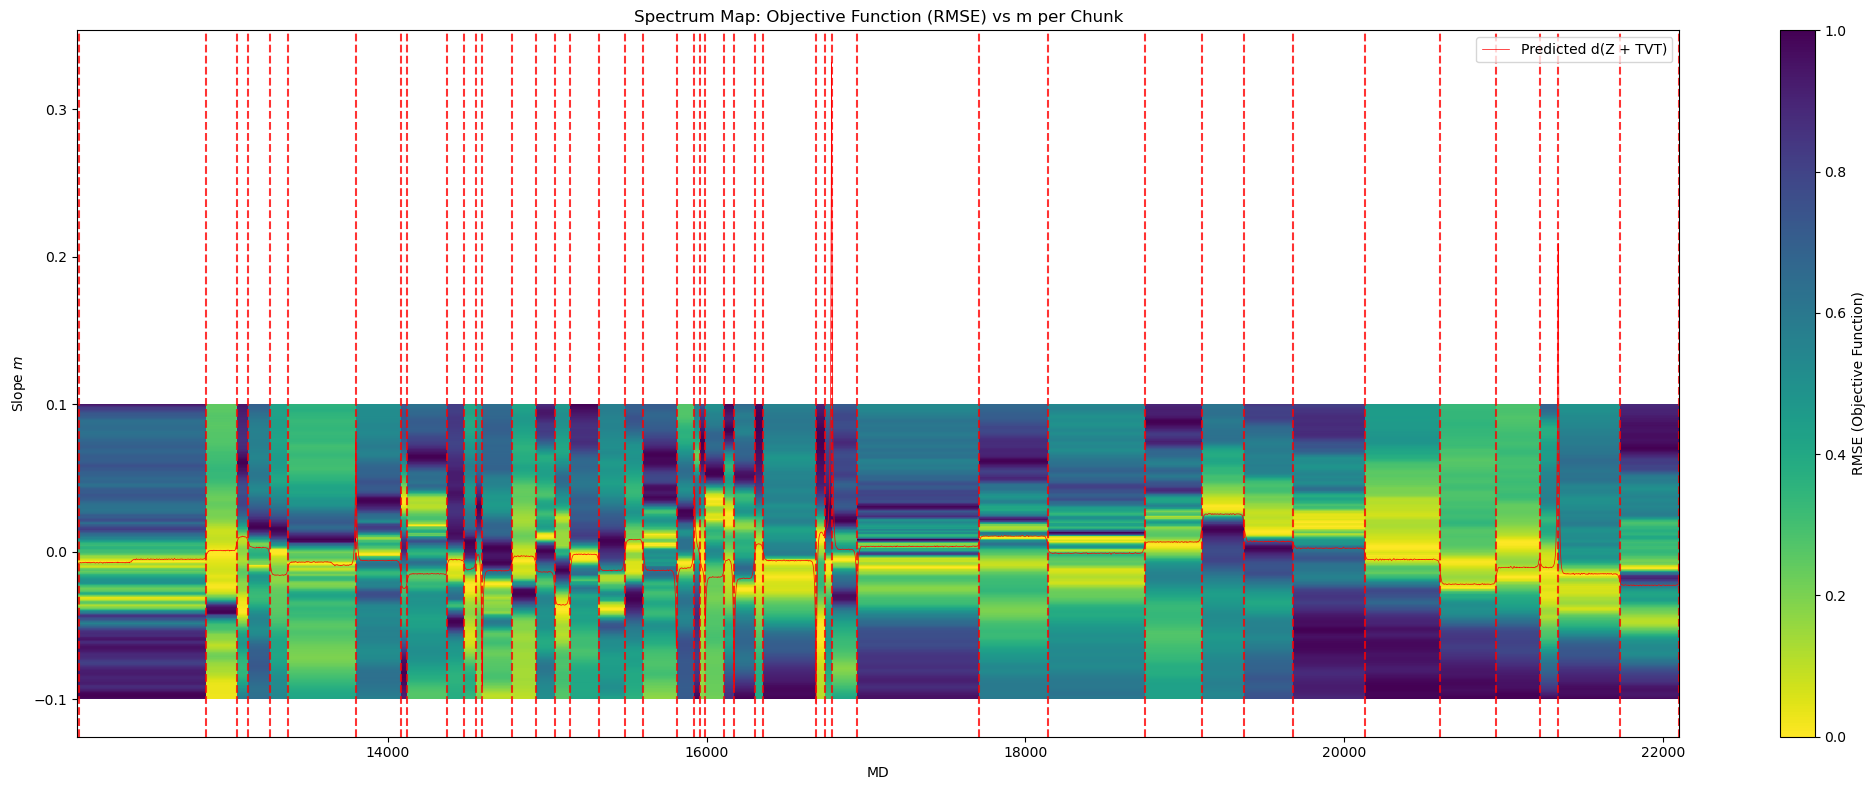

In [11]:
# Define the spectrum range for m
m_values = np.linspace(-0.1, 0.1, 500)

# Initialize a 2D array for the heatmap filled with NaNs
# Shape: (len(m_values), length of MD array)
rmse_map = np.full((len(m_values), len(evalz)), np.nan)

# Define chunk boundaries using your peaks array
boundaries = [0] + list(peaks) + [len(evalz)]

# Process each chunk independently
for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx = boundaries[i+1]
    
    chunk = evalz.iloc[start_idx:end_idx]
    if len(chunk) < 2:
        continue
        
    # Get the anchor starting value of Z+TVT for this chunk
    Z_TVT_0 = chunk['Z+TVT'].iloc[0]
    
    # Step array [0, 1, 2...] to apply the constant slope
    steps = np.arange(len(chunk))
    
    for j, m_val in enumerate(m_values):
        # Force the hypothetical constant slope m onto Z+TVT
        hypo_Z_TVT = Z_TVT_0 + (m_val * steps)
        
        # Reverse engineer TVT using the isolated norm_Z and tvt0
        hypo_TVT = hypo_Z_TVT + chunk['norm_Z'].values + tvt0
        
        # Predict GR via interpolation
        pred_GR = np.interp(hypo_TVT, tw['TVT'], tw['GR'])
        
        # Calculate Objective Function (RMSE) for the whole chunk
        # rmse = np.sqrt(np.mean((chunk['GR'].values - pred_GR)**2))
        # rmse = 1 - np.corrcoef(chunk['GR'].values, pred_GR)[0, 1]
        # rmse = np.median(np.abs(chunk['GR'].values - pred_GR))
        rmse = np.mean(np.abs(chunk['GR'].values - pred_GR))
        # rmse = np.sqrt(np.sqrt((np.mean((chunk['GR'].values - pred_GR)**4))))
        # delta = 7.0
        # err = np.abs(chunk['GR'].values - pred_GR)
        # rmse = np.mean(np.where(err < delta, 0.5 * err**2, delta * (err - 0.5 * delta)))
        # rmse = 1 - (np.dot(chunk['GR'].values, pred_GR) / (np.linalg.norm(chunk['GR'].values) * np.linalg.norm(pred_GR)))
        # from scipy.stats import spearmanr
        # rmse = 1 - spearmanr(chunk['GR'].values, pred_GR)[0]
        # rmse = np.mean(np.abs((chunk['GR'].values - pred_GR) / (chunk['GR'].values + 1e-8)))
        # rmse = np.mean((np.log1p(chunk['GR'].values) - np.log1p(pred_GR))**2)
        # rmse, path = fastdtw(chunk['GR'].values, pred_GR, dist=1)
        # err = pred_GR - chunk['GR'].values
        # weight_missed_pred = 0.7  
        # weight_extra_sensed = 0.3 
        # asymmetric_error = np.where(err > 0, err * weight_missed_pred, np.abs(err) * weight_extra_sensed)
        # rmse = np.mean(asymmetric_error)
        
        # Paint this RMSE across the entire chunk width on the map
        rmse_map[j, start_idx:end_idx] = rmse

    # Additional Normalization per Chunk
    chunk_slice = rmse_map[:, start_idx:end_idx]
    rmse_map[:, start_idx:end_idx] = (chunk_slice - np.min(chunk_slice)) / (np.max(chunk_slice) - np.min(chunk_slice))

# Plotting the Spectrum Map
fig, ax = plt.subplots(figsize=(21, 8))

# Create meshgrid for plotting
X, Y = np.meshgrid(evalz['MD'], m_values)

# Plot the heatmap (viridis_r makes lower RMSE darker/more visible)
c = ax.pcolormesh(X, Y, rmse_map, cmap='viridis_r', shading='nearest')
fig.colorbar(c, ax=ax, label='RMSE (Objective Function)')

# Overlay the actual d(Z + TVT) to see how it aligns with the RMSE minimums
ax.plot(evalz['MD'], evalz['dZ+dTVT'], color='red', linewidth=0.5, label='Predicted d(Z + TVT)')

# Mark the chunk boundaries
for pos in evalz['MD'].iloc[peaks]:
    ax.axvline(x=pos, color='red', linestyle='--', alpha=0.8)

ax.set_title('Spectrum Map: Objective Function (RMSE) vs m per Chunk')
ax.set_xlabel('MD')
ax.set_ylabel('Slope $m$')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [12]:
anchor_density = 3        # Anchors per (Z+TVT)    
max_m = 0.05              # Maximum Possible Slope
alpha = 0.0               # Penalty for sudden slope changes (DISABLED)
beta = 5               # Penalty for deviating from previous predicted TVT (Disabled)
beta = 50               # Penalty for deviating from previous predicted TVT (Disabled)

boundaries = [0] + list(peaks)[0:-1] + [len(evalz)]
# boundaries = np.linspace(0, len(evalz), 90).astype(int)
num_chunks = len(boundaries) - 1

z = evalz['norm_Z'].values
gr = (evalz['GR'].copy().values)
gr_mean = gr.mean()
gr_std = gr.std()
gr -= gr_mean
gr /= gr_std

tw_tvt = tw['TVT'].values
tw_gr = tw['GR'].copy().values
# tvt_max = np.max(tvt0 - z[0] + z + max_m * len(evalz))
# tvt_min = np.min(tvt0 - z[0] + z - max_m * len(evalz))
tvt_max = tvt0 + 15
tvt_min = tvt0 - 15
tw_mask = (tw_tvt >= tvt_min) & (tw_tvt <= tvt_max)
tw_mean = np.mean(tw_gr[tw_mask])
tw_std = np.std(tw_gr[tw_mask]) + 1e-8
tw_gr -= tw_mean
tw_gr /= tw_std

* For aleast one anchor atleast one anchor
$$2 \times (\text{max\_m} \times \text{chunk\_len}) > \frac{1}{\text{anchor\_density}}$$

In [13]:
# Anchors for chunk = (Z+TVT)_0 + m * MD
initial_anchor = -z[0] # Z + TVT, TVT_pred[0] is 0
anchors = [np.array([initial_anchor])]

for i in range(1, len(boundaries)):
    current_md_steps = boundaries[i]
    min_anchor = initial_anchor + (-max_m * current_md_steps)
    max_anchor = initial_anchor + (max_m * current_md_steps)
    
    num_candidates = (max_anchor - min_anchor) * anchor_density
    num_candidates = max(int(num_candidates), 1)
    
    anchors.append(np.linspace(min_anchor, max_anchor, num_candidates))
    
# max_m = 1

costs = [np.full(len(cands), np.inf) for cands in anchors]
tvt0s = [np.full(len(cands), np.inf) for cands in anchors]
slopes = [np.zeros(len(cands)) for cands in anchors]
backpointer = [np.zeros(len(cands), dtype=int) for cands in anchors]
costs[0][0] = 0.0
tvt0s[0][0] = tvt0

# ==========================================
# 2. PURE VITERBI FORWARD PASS
# ==========================================
for i in range(num_chunks):
    start_idx = boundaries[i]
    end_idx = boundaries[i+1]
    chunk_len = end_idx - start_idx
    
    steps = np.arange(chunk_len)
    chunk_z = z[start_idx:end_idx]
    chunk_gr = gr[start_idx:end_idx]

    # Look at every anchor in the current boundary
    for curr_k, curr_anchor in enumerate(anchors[i]):
        if costs[i][curr_k] == np.inf:
            continue
            
        base_cost = costs[i][curr_k]

        # Draw a line to every anchor in the next boundary
        for next_k, next_anchor in enumerate(anchors[i+1]):
            m = (next_anchor - curr_anchor) / chunk_len
            
            # Hard limit: Skip lines that require an impossible dip
            if abs(m) > max_m:
                continue
                
            # Simulate the trajectory for this chunk
            hypo_z_tvt = curr_anchor + (m * steps)
            hypo_tvt = hypo_z_tvt + chunk_z + tvt0
            
            # Interpolate Type Well GR
            pred_gr = np.interp(hypo_tvt, tw_tvt, tw_gr)
            
            # COST FUNCTION: Pure Shape Matching (MSE on Standardized Data)
            chunk_cost = np.sum((chunk_gr - pred_gr)**2) 
            # tvt_deviation = beta * np.sum((hypo_tvt - tvt0s[i][curr_k])**2)
            tvt_deviation = beta * (np.sum((hypo_tvt - tvt0s[i][curr_k])**2) / (chunk_len**2))
            # print(f'RMSE: {chunk_cost} , norm: {tvt_deviation}, chunk size: {chunk_len}')
            
            # ZERO REGULARIZATION: We strictly sum the raw matching costs
            total_cost = base_cost + chunk_cost + beta * tvt_deviation
            
            # RELAXATION: If this path is cheaper than the currently known path, save it
            if total_cost < costs[i+1][next_k]:
                costs[i+1][next_k] = total_cost
                slopes[i+1][next_k] = m
                backpointer[i+1][next_k] = curr_k
                tvt0s[i+1][next_k] = hypo_tvt[-1]

# ==========================================
# 3. THE BACKWARD PASS
# ==========================================
optimal_m = np.zeros(num_chunks)
optimal_anchors = np.zeros(num_chunks + 1)

# Find the absolute lowest cost at the bottom of the well
curr_k = np.argmin(costs[-1])
optimal_anchors[-1] = anchors[-1][curr_k]

# Trace the backpointers to the top
for i in range(num_chunks - 1, -1, -1):
    optimal_m[i] = slopes[i+1][curr_k]
    curr_k = backpointer[i+1][curr_k]
    optimal_anchors[i] = anchors[i][curr_k]

In [15]:
optimal_pred_gr = np.zeros(len(evalz))
optimal_pred_tvt = np.zeros(len(evalz))
optimal_pred_m = np.zeros(len(evalz))
optimal_pred_z_tvt = np.zeros(len(evalz))
tw_gr_raw = tw_gr

for i in range(num_chunks):
    start_idx = boundaries[i]
    end_idx = boundaries[i+1]
    chunk_len = end_idx - start_idx
    steps = np.arange(chunk_len)
    
    hypo_z_tvt = optimal_anchors[i] + (optimal_m[i] * steps)
    hypo_tvt = hypo_z_tvt + z[start_idx:end_idx] + tvt0
    
    optimal_pred_gr[start_idx:end_idx] = np.interp(hypo_tvt, tw_tvt, tw_gr_raw)
    optimal_pred_tvt[start_idx:end_idx] = hypo_tvt
    optimal_pred_m[start_idx:end_idx] = optimal_m[i]
    optimal_pred_z_tvt[start_idx:end_idx] = hypo_z_tvt

In [16]:
np.sqrt(np.mean((optimal_pred_tvt - evalz['TVT'])**2))

np.float64(5.62781901793298)

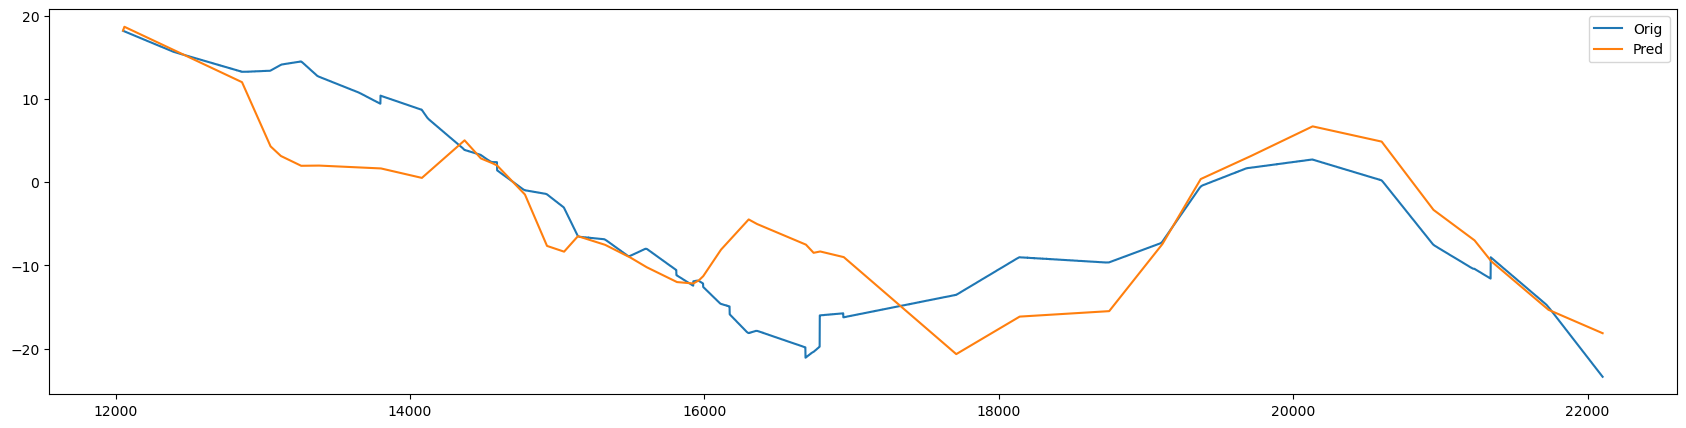

In [17]:
hypo_z_tvt
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['Z+TVT'], label='Orig') 
plt.plot(evalz['MD'], optimal_pred_z_tvt, label='Pred') 
plt.legend()

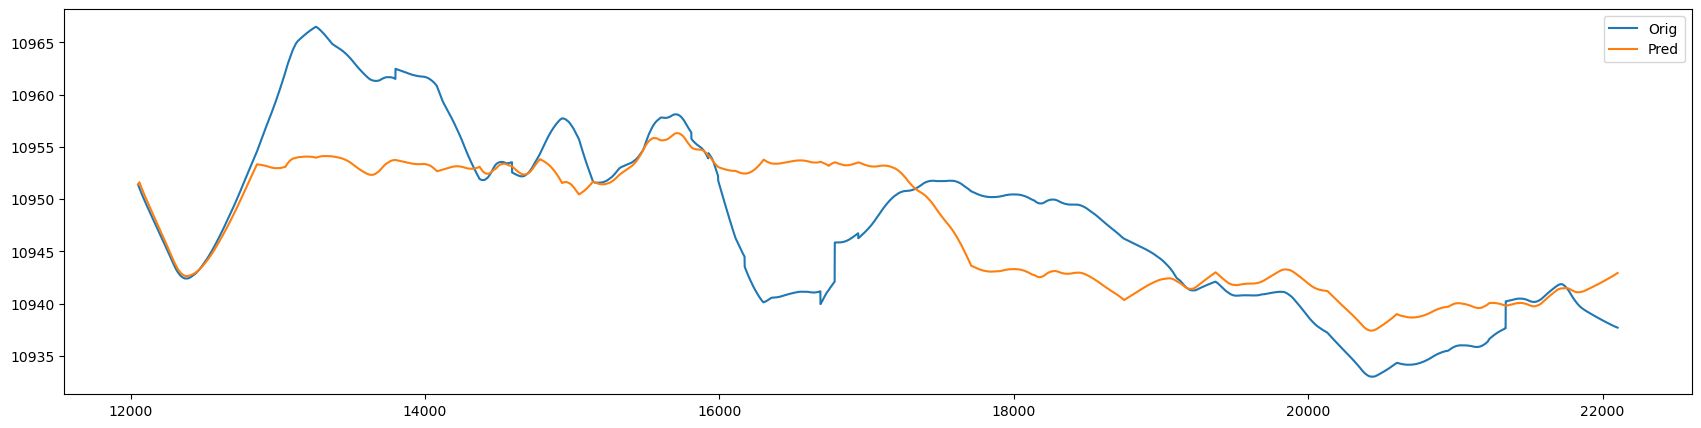

In [18]:
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['TVT'], label='Orig') 
plt.plot(evalz['MD'], optimal_pred_tvt, label='Pred') 
plt.legend()

np.float64(-0.01993365571991887)

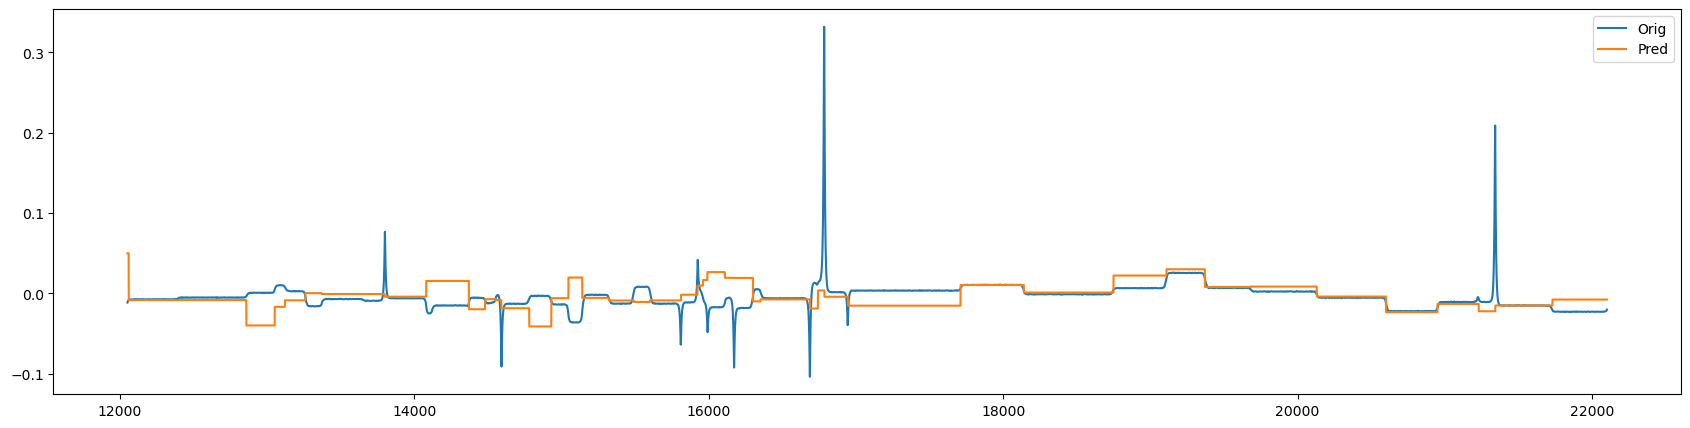

In [19]:
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['dZ+dTVT'], label='Orig') 
plt.plot(evalz['MD'], optimal_pred_m, label='Pred') 
plt.legend()
m_z

In [20]:
np.sqrt(np.mean((optimal_pred_gr - evalz['GR'])**2))
(np.mean(np.abs(optimal_pred_gr - evalz['GR'])))
np.corrcoef(optimal_pred_gr, evalz['GR'])[0, 1]

np.float64(0.8613443034063495)

In [21]:
np.sqrt(np.mean((np.interp(evalz['TVT'], tw['TVT'], tw['GR']) - evalz['GR'])**2))
(np.mean(np.abs(np.interp(evalz['TVT'], tw['TVT'], tw['GR']) - evalz['GR'])))
np.corrcoef(np.interp(evalz['TVT'], tw['TVT'], tw['GR']), evalz['GR'])[0, 1]

np.float64(0.6592444080336445)

In [22]:
optimal_m

array([ 0.05      , -0.00832602, -0.03984968, -0.01671589, -0.00860376,
        0.00031714, -0.00078639, -0.00408353,  0.0155203 ,  0.0155575 ,
       -0.01971622, -0.00714396, -0.00833595, -0.01843578, -0.04115039,
       -0.0059475 ,  0.01978588, -0.0055658 , -0.00883019, -0.0106086 ,
       -0.0087275 , -0.00162101,  0.00966   ,  0.01668728,  0.02651118,
        0.01939514,  0.01925066, -0.00991319, -0.00742578, -0.01884538,
        0.0037116 , -0.0041652 , -0.01524415,  0.01047461,  0.00107876,
        0.02224412,  0.03006065,  0.00806911,  0.00852286, -0.00390168,
       -0.02334149, -0.01309912, -0.02220997, -0.0150244 , -0.00764857])